# 건설 산업재해 분석 — 데이터 분석 노트북

**키 페이퍼**: Qurat Ul Ain, S., & Rather, K. U. I. (2025). *Annals of Epidemiology*, 108, 85-91.

**RQ**: 건설현장의 내부 안전 관리(A)와 실질적 안전 행동(B)이 산업재해 발생에 미치는 영향 — **외부 기관의 조절효과를 중심으로**.

**Data**: 제10차 산업안전보건 실태조사 (2021, 건설업), 1,375개 사업장 × 17개 변수 (전처리 완료).

**분석 단계**: EDA → 전처리 → 위계적 LR → ML → SHAP.

---
## Phase 0. 환경 설정

- `random_state=42` 전역 고정
- 한글 폰트 자동 감지
- 결과 저장: `dpi=300`, `bbox_inches='tight'`

In [1]:
import os, warnings, itertools
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

import scipy.stats as st
import statsmodels.api as sm
from statsmodels.tools.tools import add_constant
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, average_precision_score, roc_curve)
from sklearn.inspection import permutation_importance

import xgboost as xgb
import lightgbm as lgb
from imblearn.over_sampling import SMOTENC
from imblearn.pipeline import Pipeline as ImbPipeline
import shap

from IPython.display import display

warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# 한글 폰트 강제 적용 — 파일 경로로 직접 등록
import platform
if platform.system() == 'Windows':
    _font_candidates = [r'C:\Windows\Fonts\malgun.ttf', r'C:\Windows\Fonts\malgunbd.ttf', r'C:\Windows\Fonts\NanumGothic.ttf']
elif platform.system() == 'Darwin':
    _font_candidates = ['/Library/Fonts/AppleGothic.ttf', '/Library/Fonts/NanumGothic.ttf', '/System/Library/Fonts/AppleSDGothicNeo.ttc']
else:
    _font_candidates = ['/usr/share/fonts/truetype/nanum/NanumGothic.ttf', '/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc']

_font_name = None
for _fp in _font_candidates:
    if os.path.exists(_fp):
        fm.fontManager.addfont(_fp)
        _font_name = fm.FontProperties(fname=_fp).get_name()
        break

if _font_name:
    plt.rcParams['font.family'] = _font_name
    plt.rcParams['font.sans-serif'] = [_font_name, 'DejaVu Sans']
    print(f'한글 폰트 강제 적용: {_font_name}')
else:
    print('경고: 한글 폰트 미감지 — □ 박스 표시 가능')
plt.rcParams['axes.unicode_minus'] = False
sns.set_style('whitegrid')
# seaborn은 font.family를 덮어쓸 수 있어 다시 한 번 강제 적용
if _font_name:
    plt.rcParams['font.family'] = _font_name

# 경로 (notebooks/에서 실행되면 한 단계 올라감)
BASE_DIR = Path.cwd()
if BASE_DIR.name == 'notebooks':
    BASE_DIR = BASE_DIR.parent

DATA_PATH = BASE_DIR / 'data' / '전처리_최종.csv'
TABLES_DIR = BASE_DIR / 'results' / 'tables'
FIGURES_DIR = BASE_DIR / 'results' / 'figures'
TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

SAVE_KWARGS = {'dpi': 300, 'bbox_inches': 'tight'}

print(f'BASE_DIR : {BASE_DIR}')
print(f'DATA exists: {DATA_PATH.exists()}')

한글 폰트 강제 적용: Malgun Gothic
BASE_DIR : D:\새 폴더\고건\14. Dev Project\11. construction_competition_final
DATA exists: True


In [2]:
df = pd.read_csv(DATA_PATH)
print(f'shape: {df.shape}')
df.head()

shape: (1375, 17)


,안전조직수준,위원회수준,인증보유,위험성평가수준,교육훈련도움,정리정돈상태,작업중지권,작업반장기여,전문지도,고용노동부감독,안전보건공단지원,공사규모,발주처,기성공정률,공사종류,외국인비율,사고발생
0,1,0,0,2,5,4,4,4,0,0,0,1,1,6,7,0.0,0
1,1,1,0,2,5,5,5,5,0,0,0,2,2,1,6,0.0,0
2,1,1,1,2,3,3,2,2,0,1,1,3,2,6,3,20.0,1
3,1,1,0,2,5,5,5,5,0,1,1,1,2,4,4,40.0,0
4,1,1,0,2,5,5,5,5,0,0,0,1,2,3,1,60.0,1


In [3]:
# 변수 그룹 정의
TARGET = '사고발생'
VARS_A = ['안전조직수준', '위원회수준', '인증보유']                                    # 독립 A (내부 관리, 3)
VARS_B = ['위험성평가수준', '교육훈련도움', '정리정돈상태', '작업중지권', '작업반장기여']  # 독립 B (현장 행동, 5)
VARS_MOD = ['전문지도', '고용노동부감독', '안전보건공단지원']                            # 조절 (외부 기관, 3)
VARS_CONTROL_NOM = ['공사규모', '발주처', '기성공정률', '공사종류']                     # 통제 — 명목형 → 더미
VARS_CONTROL_NUM = ['외국인비율']                                                     # 통제 — 연속형
VARS_CONTROL = VARS_CONTROL_NOM + VARS_CONTROL_NUM

# 기술통계: 연속/순서형 vs 범주형
VARS_CONT_ORD = ['위험성평가수준','교육훈련도움','정리정돈상태','작업중지권','작업반장기여','외국인비율']
VARS_CAT = ['안전조직수준','위원회수준','인증보유','전문지도','고용노동부감독','안전보건공단지원',
             '공사규모','발주처','기성공정률','공사종류']

print(f'독립 A ({len(VARS_A)}): {VARS_A}')
print(f'독립 B ({len(VARS_B)}): {VARS_B}')
print(f'조절   ({len(VARS_MOD)}): {VARS_MOD}')
print(f'통제   ({len(VARS_CONTROL)}): {VARS_CONTROL}')

독립 A (3): ['안전조직수준', '위원회수준', '인증보유']
독립 B (5): ['위험성평가수준', '교육훈련도움', '정리정돈상태', '작업중지권', '작업반장기여']
조절   (3): ['전문지도', '고용노동부감독', '안전보건공단지원']
통제   (5): ['공사규모', '발주처', '기성공정률', '공사종류', '외국인비율']


---
## Phase 1. 탐색적 데이터 분석 (EDA)

In [4]:
# Table 1 — 연속/순서형 기술통계 + 독립표본 t-test (Welch)
rows = []
for v in VARS_CONT_ORD:
    g0 = df.loc[df[TARGET]==0, v]
    g1 = df.loc[df[TARGET]==1, v]
    t, p = st.ttest_ind(g0, g1, equal_var=False)
    rows.append({
        '변수': v,
        '전체 평균±SD': f'{df[v].mean():.2f}±{df[v].std():.2f}',
        '미발생군 평균±SD': f'{g0.mean():.2f}±{g0.std():.2f}',
        '발생군 평균±SD':  f'{g1.mean():.2f}±{g1.std():.2f}',
        't': round(t, 3),
        'p값': round(p, 4),
        '유의도': '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else ''
    })
table1 = pd.DataFrame(rows)
table1.to_csv(TABLES_DIR/'table1_기술통계_연속.csv', index=False, encoding='utf-8-sig')
display(table1)

,변수,전체 평균±SD,미발생군 평균±SD,발생군 평균±SD,t,p값,유의도
0,위험성평가수준,1.78±0.59,1.75±0.62,1.83±0.50,-2.560,0.0106,*
1,교육훈련도움,4.31±0.74,4.33±0.73,4.26±0.76,1.418,0.1565,
2,정리정돈상태,4.22±0.76,4.26±0.72,4.11±0.84,3.231,0.0013,**
3,작업중지권,4.35±0.75,4.35±0.73,4.34±0.80,0.258,0.7968,
4,작업반장기여,4.13±0.82,4.16±0.78,4.05±0.90,2.113,0.0350,*
5,외국인비율,13.30±19.02,11.25±18.16,18.46±20.14,-6.146,0.0000,***


In [5]:
# Table 2 — 범주형 기술통계 + χ² 검정
rows = []
for v in VARS_CAT:
    ct = pd.crosstab(df[v], df[TARGET])
    chi2, p, dof, _ = st.chi2_contingency(ct)
    rows.append({
        '변수': v,
        '범주수': df[v].nunique(),
        '관측수': int(df[v].count()),
        'χ²': round(chi2, 3),
        'df': int(dof),
        'p값': round(p, 4),
        '유의도': '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else ''
    })
table2 = pd.DataFrame(rows)
table2.to_csv(TABLES_DIR/'table2_기술통계_범주형.csv', index=False, encoding='utf-8-sig')
display(table2)

,변수,범주수,관측수,χ²,df,p값,유의도
0,안전조직수준,2,1375,1.538,1,0.2149,
1,위원회수준,2,1375,2.047,1,0.1525,
2,인증보유,2,1375,1.040,1,0.3078,
3,전문지도,2,1375,0.079,1,0.7783,
4,고용노동부감독,2,1375,41.050,1,0.0000,***
5,안전보건공단지원,2,1375,23.261,1,0.0000,***
6,공사규모,3,1375,35.776,2,0.0000,***
7,발주처,3,1375,21.680,2,0.0000,***
8,기성공정률,6,1375,105.819,5,0.0000,***
9,공사종류,7,1375,52.407,6,0.0000,***


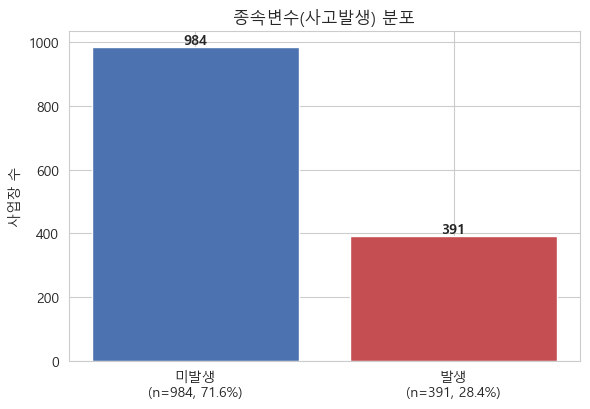

In [6]:
# Fig 1 — 종속변수 분포
fig, ax = plt.subplots(figsize=(6, 4.2))
counts = df[TARGET].value_counts().sort_index()
labels = [f'미발생\n(n={counts[0]:,}, {counts[0]/len(df):.1%})',
          f'발생\n(n={counts[1]:,}, {counts[1]/len(df):.1%})']
bars = ax.bar(labels, counts.values, color=['#4C72B0', '#C44E52'])
ax.set_ylabel('사업장 수')
ax.set_title('종속변수(사고발생) 분포')
for b, v in zip(bars, counts.values):
    ax.text(b.get_x()+b.get_width()/2, v+counts.values.max()*0.01, f'{v:,}',
            ha='center', fontweight='bold')
plt.tight_layout()
fig.savefig(FIGURES_DIR/'fig1_종속변수분포.png', **SAVE_KWARGS)
plt.show()

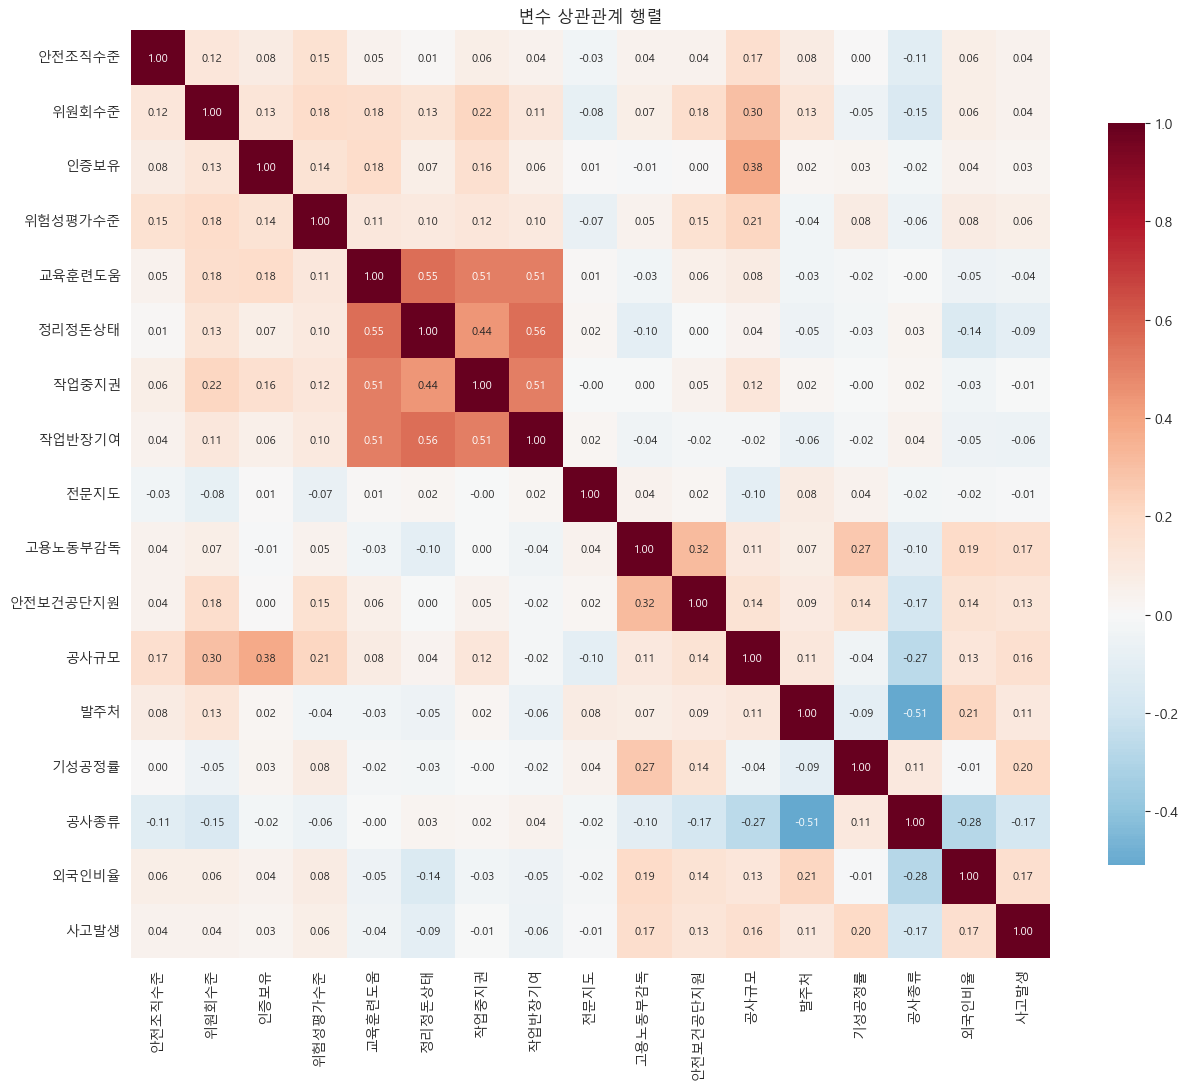

In [7]:
# 상관관계 히트맵
ALL_VARS = VARS_A + VARS_B + VARS_MOD + VARS_CONTROL + [TARGET]
corr = df[ALL_VARS].corr()
fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            cbar_kws={'shrink': 0.8}, ax=ax, annot_kws={'size': 8})
ax.set_title('변수 상관관계 행렬')
plt.tight_layout()
fig.savefig(FIGURES_DIR/'fig_상관관계.png', **SAVE_KWARGS)
plt.show()

---
## Phase 2. 전처리 (Data Leakage 방지)

1. 명목형 4개 → 더미 변환 (15개 더미)
2. Train/Test **8:2 stratified split** (`random_state=42`)
3. **Z-score 표준화** — train에서 fit → test에 transform (LR 전용)
4. **트리 모델용** — 표준화 없음 (원자료 그대로)
5. **SMOTENC** — 학습셋 한정, `imblearn.pipeline.Pipeline`으로 CV fold 내부 적용 (Phase 4에서)

In [8]:
# 더미 변환 — 명시적 baseline drop
BASELINES = {
    '공사규모':   2,   # 중규모 120~800억 미만
    '발주처':     2,   # 사기업·개인
    '기성공정률': 3,   # 30~50% 미만
    '공사종류':   7,   # 전기·통신·기타
}

def make_dummies(data, baselines):
    out = data.copy()
    for col, baseline in baselines.items():
        d = pd.get_dummies(out[col], prefix=col, dtype=int)
        drop_col = f'{col}_{baseline}'
        if drop_col in d.columns:
            d = d.drop(columns=drop_col)
        out = out.drop(columns=col)
        out = pd.concat([out, d], axis=1)
    return out

df_enc = make_dummies(df, BASELINES)

DUMMY_COLS = []
for col, baseline in BASELINES.items():
    for v in sorted(df[col].unique()):
        if v != baseline:
            DUMMY_COLS.append(f'{col}_{v}')

CONTROL_COLS = DUMMY_COLS + VARS_CONTROL_NUM           # 15 + 1 = 16
FEATURE_COLS = CONTROL_COLS + VARS_A + VARS_B + VARS_MOD  # 16 + 3 + 5 + 3 = 27

print(f'DUMMY_COLS  ({len(DUMMY_COLS)}): {DUMMY_COLS}')
print(f'CONTROL_COLS({len(CONTROL_COLS)}) — 더미 15 + 외국인비율 1')
print(f'FEATURE_COLS({len(FEATURE_COLS)}) — 통제 16 + A 3 + B 5 + 조절 3')

DUMMY_COLS  (15): ['공사규모_1', '공사규모_3', '발주처_1', '발주처_3', '기성공정률_1', '기성공정률_2', '기성공정률_4', '기성공정률_5', '기성공정률_6', '공사종류_1', '공사종류_2', '공사종류_3', '공사종류_4', '공사종류_5', '공사종류_6']
CONTROL_COLS(16) — 더미 15 + 외국인비율 1
FEATURE_COLS(27) — 통제 16 + A 3 + B 5 + 조절 3


In [9]:
# Train/Test split + Z-score (LR 전용)
X = df_enc[FEATURE_COLS].astype(float).copy()
y = df_enc[TARGET].astype(int).copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

scaler = StandardScaler()
X_train_z = pd.DataFrame(scaler.fit_transform(X_train), columns=FEATURE_COLS, index=X_train.index)
X_test_z  = pd.DataFrame(scaler.transform(X_test),       columns=FEATURE_COLS, index=X_test.index)

print(f'Train: {X_train.shape}   target {y_train.value_counts().to_dict()}')
print(f'Test : {X_test.shape}    target {y_test.value_counts().to_dict()}')

Train: (1100, 27)   target {0: 787, 1: 313}
Test : (275, 27)    target {0: 197, 1: 78}


In [10]:
# Table 3 — VIF (z-scored 학습셋 기준)
X_vif = add_constant(X_train_z)
vif_rows = []
for i, col in enumerate(X_vif.columns):
    if col == 'const':
        continue
    vif_rows.append({'변수': col, 'VIF': round(variance_inflation_factor(X_vif.values, i), 3)})
table3 = pd.DataFrame(vif_rows).sort_values('VIF', ascending=False).reset_index(drop=True)
table3.to_csv(TABLES_DIR/'table3_VIF.csv', index=False, encoding='utf-8-sig')

print(f'최대 VIF: {table3.VIF.max():.3f}  /  기준: < 5')
display(table3)

최대 VIF: 4.818  /  기준: < 5


,변수,VIF
0,공사종류_1,4.818
1,공사종류_3,3.883
2,공사종류_4,3.140
3,공사종류_5,2.351
4,공사종류_6,2.340
5,기성공정률_1,1.887
6,발주처_1,1.840
7,기성공정률_2,1.840
8,작업반장기여,1.827
9,정리정돈상태,1.825


---
## Phase 3. 위계적 로지스틱 회귀

- **M1**: 통제 (16)
- **M2**: M1 + 독립 A (3)
- **M3**: M2 + 독립 B (5)
- **M4**: M3 + 조절 (3)
- **M5**: M4 + 상호작용 (독립 8 × 조절 3 = 24)

In [11]:
# 상호작용항 (z-score 후 곱: Aiken & West 표준)
INTERACTION_PAIRS = list(itertools.product(VARS_A + VARS_B, VARS_MOD))   # 8 × 3 = 24
INTERACTION_COLS = [f'{x}__x__{m}' for (x, m) in INTERACTION_PAIRS]

X_train_full = X_train_z.copy()
X_test_full  = X_test_z.copy()
for (x, m) in INTERACTION_PAIRS:
    col = f'{x}__x__{m}'
    X_train_full[col] = X_train_z[x] * X_train_z[m]
    X_test_full[col]  = X_test_z[x]  * X_test_z[m]

cols_M1 = CONTROL_COLS
cols_M2 = cols_M1 + VARS_A
cols_M3 = cols_M2 + VARS_B
cols_M4 = cols_M3 + VARS_MOD
cols_M5 = cols_M4 + INTERACTION_COLS

def fit_logit(cols):
    X_ = add_constant(X_train_full[cols].astype(float))
    return sm.Logit(y_train, X_).fit(disp=0, maxiter=200)

m1, m2, m3, m4, m5 = (fit_logit(c) for c in [cols_M1, cols_M2, cols_M3, cols_M4, cols_M5])
print(f'M1: {len(cols_M1)} cols | M2: {len(cols_M2)} | M3: {len(cols_M3)} | M4: {len(cols_M4)} | M5: {len(cols_M5)}')

M1: 16 cols | M2: 19 | M3: 24 | M4: 27 | M5: 51


In [12]:
# Table 4 — 위계적 모형 비교
def model_row(model, name):
    return {
        '모형': name,
        '예측변수 수': int(model.df_model),
        'Log-Likelihood': round(model.llf, 3),
        'McFadden R²': round(model.prsquared, 4),
        'AIC': round(model.aic, 2),
        'BIC': round(model.bic, 2),
    }

table4 = pd.DataFrame([
    model_row(m1, 'M1 (통제)'),
    model_row(m2, 'M2 (+A 내부관리)'),
    model_row(m3, 'M3 (+B 현장행동)'),
    model_row(m4, 'M4 (+조절)'),
    model_row(m5, 'M5 (+상호작용 24)'),
])
table4.to_csv(TABLES_DIR/'table4_LR_위계비교.csv', index=False, encoding='utf-8-sig')
display(table4)

,모형,예측변수 수,Log-Likelihood,McFadden R²,AIC,BIC
0,M1 (통제),16,-558.703,0.1495,1151.41,1236.46
1,M2 (+A 내부관리),19,-557.578,0.1512,1155.16,1255.22
2,M3 (+B 현장행동),24,-555.681,0.1541,1161.36,1286.44
3,M4 (+조절),27,-554.103,0.1565,1164.21,1304.29
4,M5 (+상호작용 24),51,-544.287,0.1714,1192.57,1452.73


In [13]:
# Table 5 — 우도비 검정 (M1→M2, M2→M3, M3→M4, M4→M5)
def lr_test(restricted, full):
    lr_stat = 2 * (full.llf - restricted.llf)
    df_diff = full.df_model - restricted.df_model
    p = 1 - st.chi2.cdf(lr_stat, df_diff)
    dr2 = full.prsquared - restricted.prsquared
    return lr_stat, int(df_diff), p, dr2

comparisons = [
    ('M1 → M2 (+A)',       m1, m2),
    ('M2 → M3 (+B)',       m2, m3),
    ('M3 → M4 (+조절)',     m3, m4),
    ('M4 → M5 (+상호작용)', m4, m5),
]
rows = []
for name, r, f in comparisons:
    lr, dof, p, dr2 = lr_test(r, f)
    rows.append({
        '비교': name,
        'LR statistic': round(lr, 3),
        'df': dof,
        'p값': round(p, 5),
        'ΔR²': round(dr2, 5),
        '유의도': '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else ''
    })
table5 = pd.DataFrame(rows)
table5.to_csv(TABLES_DIR/'table5_LR_우도비검정.csv', index=False, encoding='utf-8-sig')
display(table5)

,비교,LR statistic,df,p값,ΔR²,유의도
0,M1 → M2 (+A),2.251,3,0.52192,0.00171,
1,M2 → M3 (+B),3.793,5,0.57964,0.00289,
2,M3 → M4 (+조절),3.157,3,0.36802,0.00240,
3,M4 → M5 (+상호작용),19.631,24,0.71757,0.01494,


In [14]:
# 계수 추출 헬퍼
def coef_table(model, cols_to_show):
    out = []
    p_ = model.params
    se = model.bse
    z  = model.tvalues
    pv = model.pvalues
    ci = model.conf_int()
    for c in cols_to_show:
        if c not in p_.index:
            continue
        b = p_[c]
        out.append({
            '변수': c,
            'β': round(b, 4),
            'SE': round(se[c], 4),
            'z': round(z[c], 3),
            'p값': round(pv[c], 4),
            'OR': round(np.exp(b), 4),
            'OR 95%CI 하한': round(np.exp(ci.loc[c, 0]), 4),
            'OR 95%CI 상한': round(np.exp(ci.loc[c, 1]), 4),
            '유의도': '***' if pv[c]<0.001 else '**' if pv[c]<0.01 else '*' if pv[c]<0.05 else ''
        })
    return pd.DataFrame(out)

# Table 6 — M5 주효과 (상호작용 제외)
table6 = coef_table(m5, ['const'] + cols_M4)
table6.to_csv(TABLES_DIR/'table6_LR_M5주효과.csv', index=False, encoding='utf-8-sig')
display(table6)

,변수,β,SE,z,p값,OR,OR 95%CI 하한,OR 95%CI 상한,유의도
0,const,-1.2568,0.0930,-13.521,0.0000,0.2846,0.2372,0.3414,***
1,공사규모_1,-0.3645,0.0942,-3.868,0.0001,0.6946,0.5774,0.8354,***
2,공사규모_3,0.1703,0.0887,1.919,0.0549,1.1856,0.9964,1.4108,
3,발주처_1,-0.1747,0.1028,-1.699,0.0893,0.8397,0.6865,1.0272,
4,발주처_3,-0.0420,0.0802,-0.523,0.6008,0.9589,0.8193,1.1222,
5,기성공정률_1,-0.8533,0.1352,-6.312,0.0000,0.4260,0.3269,0.5553,***
6,기성공정률_2,-0.3703,0.0970,-3.817,0.0001,0.6905,0.5709,0.8351,***
7,기성공정률_4,0.1375,0.0858,1.603,0.1089,1.1474,0.9699,1.3574,
8,기성공정률_5,-0.0958,0.0881,-1.087,0.2768,0.9086,0.7646,1.0799,
9,기성공정률_6,0.0186,0.0841,0.222,0.8247,1.0188,0.8640,1.2013,


In [15]:
# Table 7 — 24개 상호작용항 (p값 오름차순, p<0.20 강조)
table7 = coef_table(m5, INTERACTION_COLS)
table7['p<0.20'] = table7['p값'] < 0.20
table7 = table7.sort_values('p값').reset_index(drop=True)
table7.to_csv(TABLES_DIR/'table7_LR_조절효과24쌍.csv', index=False, encoding='utf-8-sig')
print(f'유의 (p<0.05): {(table7["p값"]<0.05).sum()} / 24')
print(f'경향 (p<0.20): {table7["p<0.20"].sum()} / 24')
display(table7)

유의 (p<0.05): 0 / 24
경향 (p<0.20): 3 / 24


,변수,β,SE,z,p값,OR,OR 95%CI 하한,OR 95%CI 상한,유의도,p<0.20
0,작업반장기여__x__전문지도,-0.1833,0.0954,-1.921,0.0547,0.8325,0.6905,1.0037,,True
1,인증보유__x__고용노동부감독,0.1608,0.0866,1.856,0.0634,1.1744,0.9911,1.3917,,True
2,작업중지권__x__전문지도,0.1363,0.0949,1.437,0.1508,1.1461,0.9516,1.3803,,True
3,위험성평가수준__x__고용노동부감독,-0.1277,0.1022,-1.250,0.2114,0.8801,0.7203,1.0753,,False
4,위험성평가수준__x__안전보건공단지원,0.1089,0.0954,1.142,0.2536,1.1151,0.9249,1.3444,,False
5,위원회수준__x__고용노동부감독,-0.1018,0.0911,-1.118,0.2635,0.9032,0.7556,1.0797,,False
6,정리정돈상태__x__고용노동부감독,0.1138,0.1061,1.073,0.2833,1.1205,0.9102,1.3794,,False
7,작업반장기여__x__고용노동부감독,-0.1001,0.1036,-0.966,0.3341,0.9048,0.7385,1.1085,,False
8,정리정돈상태__x__전문지도,0.0905,0.0969,0.934,0.3500,1.0948,0.9054,1.3237,,False
9,안전조직수준__x__전문지도,-0.0923,0.1006,-0.917,0.3590,0.9119,0.7487,1.1106,,False


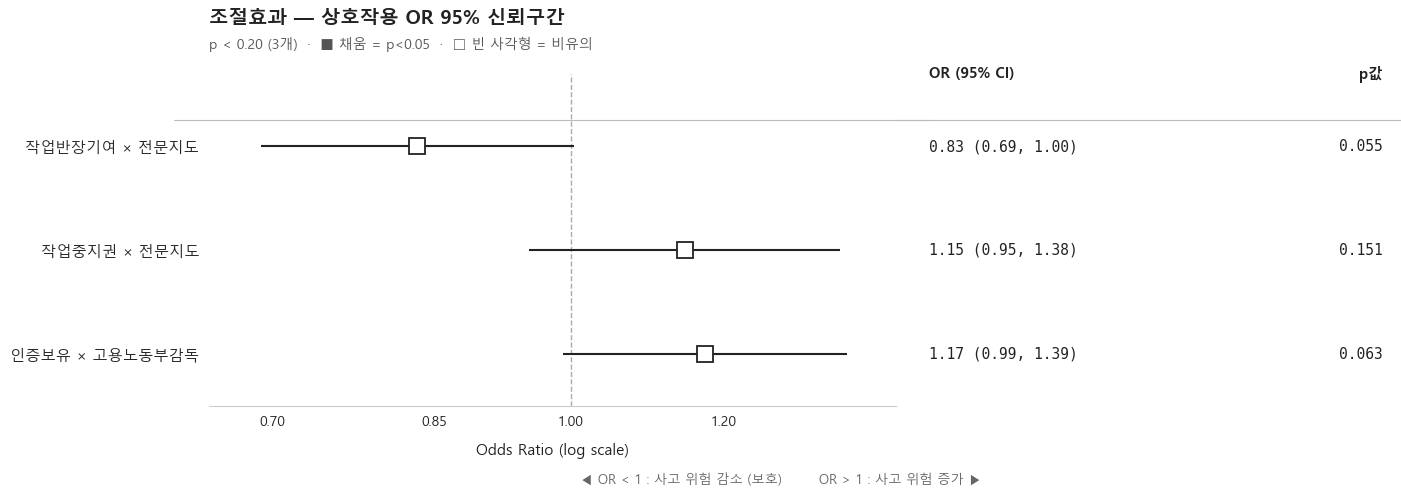

In [16]:
# Fig 2 - 표준 forest plot (GridSpec 2패널: 포레스트 + 텍스트테이블)
import matplotlib.gridspec as gridspec
from matplotlib.ticker import FixedLocator, ScalarFormatter, NullFormatter

sig = table7[table7['p값'] < 0.20].copy().sort_values('OR').reset_index(drop=True)
sig['변수표시'] = sig['변수'].str.replace('__x__', ' × ', regex=False)

if len(sig):
    n = len(sig)
    fig = plt.figure(figsize=(13, n * 0.85 + 2.8))
    gs = gridspec.GridSpec(1, 2, width_ratios=[3.2, 2.2], wspace=0.04,
                            left=0.06, right=0.97, top=0.82, bottom=0.20)
    ax  = fig.add_subplot(gs[0, 0])
    axt = fig.add_subplot(gs[0, 1])

    # 좌: Forest plot
    for i, row in sig.iterrows():
        is_sig = row['p값'] < 0.05
        facecolor = '#222' if is_sig else 'white'
        ax.errorbar(row['OR'], i,
                    xerr=[[row['OR']-row['OR 95%CI 하한']], [row['OR 95%CI 상한']-row['OR']]],
                    fmt='s', capsize=0,
                    ecolor='#222', mfc=facecolor, mec='#222', mew=1.3,
                    markersize=11, lw=1.5, zorder=3)
    ax.axvline(1.0, color='#888', linestyle='--', alpha=0.7, lw=1.0, zorder=1)
    ax.set_yticks(range(n))
    ax.set_yticklabels(sig['변수표시'].tolist(), fontsize=11)
    ax.set_ylim(n - 0.5, -0.7)
    ax.set_xscale('log')
    or_min = sig['OR 95%CI 하한'].min() * 0.94
    or_max = sig['OR 95%CI 상한'].max() * 1.06
    ax.set_xlim(or_min, or_max)
    ax.xaxis.set_major_locator(FixedLocator([0.5, 0.7, 0.85, 1.0, 1.2, 1.5, 2.0]))
    ax.xaxis.set_major_formatter(ScalarFormatter())
    ax.xaxis.set_minor_formatter(NullFormatter())
    ax.set_xlabel('Odds Ratio (log scale)', fontsize=11, color='#222', labelpad=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.tick_params(axis='y', left=False)
    ax.tick_params(axis='x', colors='#222')
    ax.grid(False)

    # 우: 텍스트 테이블
    axt.set_xlim(0, 1)
    axt.set_ylim(n - 0.5, -0.7)
    axt.axis('off')
    HEADER_Y = -0.7
    axt.text(0.02, HEADER_Y, 'OR (95% CI)', va='center', ha='left',
             fontsize=10.5, fontweight='bold', color='#222')
    axt.text(0.98, HEADER_Y, 'p값', va='center', ha='right',
             fontsize=10.5, fontweight='bold', color='#222')
    for i, row in sig.iterrows():
        or_str = f"{row['OR']:.2f} ({row['OR 95%CI 하한']:.2f}, {row['OR 95%CI 상한']:.2f})"
        p_str = f"{row['p값']:.3f}"
        weight = 'bold' if row['p값'] < 0.05 else 'normal'
        axt.text(0.02, i, or_str, va='center', ha='left',
                 fontsize=10.5, family='DejaVu Sans Mono', color='#222')
        axt.text(0.98, i, p_str, va='center', ha='right',
                 fontsize=10.5, family='DejaVu Sans Mono', color='#222',
                 fontweight=weight)

    # 헤더 구분선
    ax.axhline(-0.25, color='#bbb', lw=0.8, xmin=-0.05, xmax=1.05, clip_on=False)
    axt.axhline(-0.25, color='#bbb', lw=0.8, xmin=-0.05, xmax=1.05, clip_on=False)

    # 제목·부제목·하단
    fig.text(0.06, 0.94, '조절효과 — 상호작용 OR 95% 신뢰구간',
             fontsize=14, fontweight='bold', color='#222', va='top')
    fig.text(0.06, 0.89, f'p < 0.20 ({n}개)  ·  ■ 채움 = p<0.05  ·  □ 빈 사각형 = 비유의',
             fontsize=10, color='#555', va='top')
    fig.text(0.50, 0.06, '◀ OR < 1 : 사고 위험 감소 (보호)        OR > 1 : 사고 위험 증가 ▶',
             fontsize=9.5, color='#666', ha='center', va='center')

    fig.savefig(FIGURES_DIR/'fig2_상호작용효과.png', **SAVE_KWARGS)
    plt.show()
else:
    print('유의한 상호작용 없음 (p<0.20)')


---
## Phase 4. 머신러닝 모델 비교

4개 모델 (LR / RF / XGBoost / LightGBM) × 5-Fold Stratified CV × GridSearchCV(scoring='f1')

- SMOTENC는 `ImbPipeline`으로 CV fold 학습셋에만 적용 (test fold 미오염)
- LR만 `StandardScaler` 포함, 트리 계열은 미적용

In [17]:
# SMOTENC categorical_features — 더미·이진 위치
categorical_set = set(DUMMY_COLS + VARS_A + VARS_MOD)
categorical_idx = [i for i, c in enumerate(FEATURE_COLS) if c in categorical_set]
print(f'SMOTENC categorical 변수 수: {len(categorical_idx)} / {len(FEATURE_COLS)}')

def make_pipeline(model, scaled=False):
    smote = SMOTENC(categorical_features=categorical_idx, random_state=RANDOM_STATE)
    steps = [('smote', smote)]
    if scaled:
        steps.append(('scaler', StandardScaler()))
    steps.append(('model', model))
    return ImbPipeline(steps)

models_grid = {
    'LR':  (make_pipeline(LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
                           scaled=True),
            {'model__C': [0.1, 1.0, 10.0]}),
    'RF':  (make_pipeline(RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)),
            {'model__n_estimators': [200, 400],
             'model__max_depth':    [None, 8, 12]}),
    'XGBoost': (make_pipeline(xgb.XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss',
                                                 n_jobs=-1, verbosity=0)),
                {'model__n_estimators':  [200, 400],
                 'model__max_depth':     [3, 5, 7],
                 'model__learning_rate': [0.05, 0.1]}),
    'LightGBM': (make_pipeline(lgb.LGBMClassifier(random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)),
                 {'model__n_estimators':  [200, 400],
                  'model__num_leaves':    [15, 31, 63],
                  'model__learning_rate': [0.05, 0.1]}),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

SMOTENC categorical 변수 수: 21 / 27


In [18]:
# GridSearchCV — 4모델
results = {}
gs_objects = {}
for name, (pipe, grid) in models_grid.items():
    print(f'>>> {name} GridSearch...')
    gs = GridSearchCV(pipe, grid, scoring='f1', cv=cv, n_jobs=-1, refit=True)
    gs.fit(X_train, y_train)
    gs_objects[name] = gs
    pred  = gs.predict(X_test)
    proba = gs.predict_proba(X_test)[:, 1]
    results[name] = {
        '정확도':  round(accuracy_score(y_test, pred), 4),
        '정밀도':  round(precision_score(y_test, pred), 4),
        '재현율':  round(recall_score(y_test, pred), 4),
        'F1':      round(f1_score(y_test, pred), 4),
        'ROC-AUC': round(roc_auc_score(y_test, proba), 4),
        'PR-AUC':  round(average_precision_score(y_test, proba), 4),
        'CV F1':   round(gs.best_score_, 4),
        '최적 하이퍼파라미터': gs.best_params_,
    }
    print(f'    F1={results[name]["F1"]:.3f}  AUC={results[name]["ROC-AUC"]:.3f}')

# Table 8 — 모델 비교
table8 = pd.DataFrame(results).T
table8.to_csv(TABLES_DIR/'table8_ML성능비교.csv', encoding='utf-8-sig')
display(table8)

>>> LR GridSearch...


    F1=0.497  AUC=0.704
>>> RF GridSearch...


    F1=0.517  AUC=0.705
>>> XGBoost GridSearch...


    F1=0.491  AUC=0.694
>>> LightGBM GridSearch...


    F1=0.466  AUC=0.703


,정확도,정밀도,재현율,F1,ROC-AUC,PR-AUC,CV F1,최적 하이퍼파라미터
LR,0.6545,0.4234,0.6026,0.4974,0.7038,0.4656,0.4854,{'model__C': 0.1}
RF,0.6873,0.46,0.5897,0.5169,0.7052,0.4424,0.5207,"{'model__max_depth': 8, 'model__n_estimators':..."
XGBoost,0.6982,0.4706,0.5128,0.4908,0.6943,0.4389,0.4741,"{'model__learning_rate': 0.05, 'model__max_dep..."
LightGBM,0.6836,0.4471,0.4872,0.4663,0.7028,0.4772,0.4546,"{'model__learning_rate': 0.05, 'model__n_estim..."


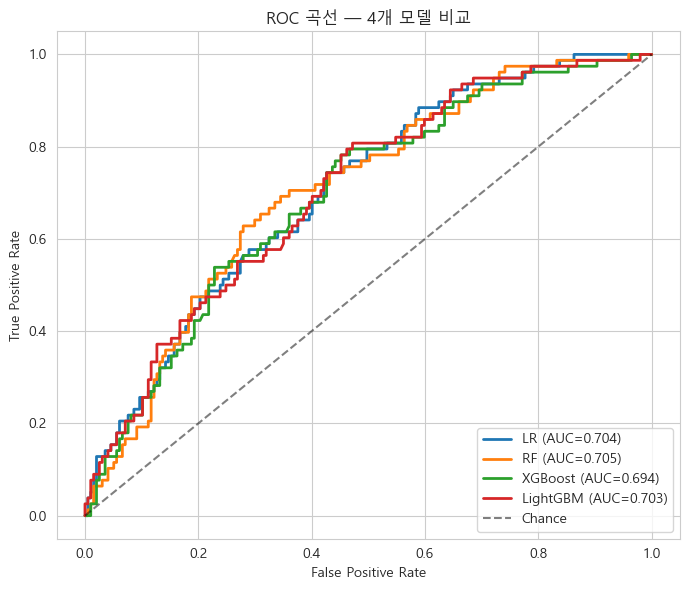

In [19]:
# Fig 3 — ROC 곡선 4개 모델 비교
fig, ax = plt.subplots(figsize=(7, 6))
for name in models_grid:
    proba = gs_objects[name].predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax.plot(fpr, tpr, lw=2, label=f'{name} (AUC={results[name]["ROC-AUC"]:.3f})')
ax.plot([0,1], [0,1], 'k--', alpha=0.5, label='Chance')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC 곡선 — 4개 모델 비교')
ax.legend(loc='lower right')
plt.tight_layout()
fig.savefig(FIGURES_DIR/'fig3_ROC곡선.png', **SAVE_KWARGS)
plt.show()

In [20]:
# 최적 모델 선정 (F1 + ROC-AUC 합산)
score_df = pd.DataFrame(results).T[['F1', 'ROC-AUC']].astype(float)
score_df['composite'] = score_df['F1'] + score_df['ROC-AUC']
best_name = score_df['composite'].idxmax()

print(f'최적 모델: {best_name}')
print(score_df.sort_values('composite', ascending=False))

최적 모델: RF
              F1  ROC-AUC  composite
RF        0.5169   0.7052     1.2221
LR        0.4974   0.7038     1.2012
XGBoost   0.4908   0.6943     1.1851
LightGBM  0.4663   0.7028     1.1691


---
## Phase 5. SHAP 분석

**핵심 원칙**: 모델 학습 1번, SHAP 계산 1번. 시각화에서만 변수 필터링.

1. 전체 27변수 SHAP (TreeExplainer)
2. 독립·조절 11변수만 — *재학습/재계산 없이* 컬럼 필터
3. 정리정돈상태 임계값 분석
4. Permutation Importance × SHAP × LR p-value 삼중 비교
5. 24쌍 SHAP 상호작용 히트맵

In [21]:
# SHAP 분석 모델 — TreeExplainer 필요. best_name이 LR이면 RF로 폴백
shap_name = 'RF' if best_name == 'LR' else best_name
shap_gs = gs_objects[shap_name]
shap_model = shap_gs.best_estimator_.named_steps['model']
print(f'SHAP 분석 모델: {shap_name} (최적={best_name})')

explainer = shap.TreeExplainer(shap_model)
shap_raw = explainer.shap_values(X_test)

# 이진 분류기: 다양한 SHAP 버전 호환 (Explanation, list, 3D, 2D)
if hasattr(shap_raw, 'values'):
    sv = shap_raw.values
    shap_values = sv[..., 1] if sv.ndim == 3 else sv
elif isinstance(shap_raw, list):
    shap_values = shap_raw[1]
elif np.ndim(shap_raw) == 3:
    shap_values = np.array(shap_raw)[..., 1]
else:
    shap_values = np.array(shap_raw)

print(f'SHAP shape: {shap_values.shape}  (Test {X_test.shape[0]} × Feat {X_test.shape[1]})')

SHAP 분석 모델: RF (최적=RF)


SHAP shape: (275, 27)  (Test 275 × Feat 27)


In [22]:
# Table 9a - 전체 27변수 SHAP mean|SHAP|
mean_abs = np.abs(shap_values).mean(axis=0)
table9a = pd.DataFrame({'변수': FEATURE_COLS,
                        'mean|SHAP|': np.round(mean_abs, 5)})
table9a = table9a.sort_values('mean|SHAP|', ascending=False).reset_index(drop=True)
table9a.insert(0, '순위', np.arange(1, len(table9a)+1))
table9a.to_csv(TABLES_DIR/'table9a_SHAP중요도_전체.csv', index=False, encoding='utf-8-sig')
print('Top 10 (전체 27변수):')
display(table9a.head(10))


Top 10 (전체 27변수):


,순위,변수,mean|SHAP|
0,1,기성공정률_1,0.07473
1,2,공사규모_1,0.04540
2,3,안전보건공단지원,0.04506
3,4,기성공정률_2,0.04062
4,5,고용노동부감독,0.03615
5,6,발주처_1,0.03363
6,7,외국인비율,0.03244
7,8,공사종류_6,0.02050
8,9,정리정돈상태,0.01829
9,10,위원회수준,0.01712


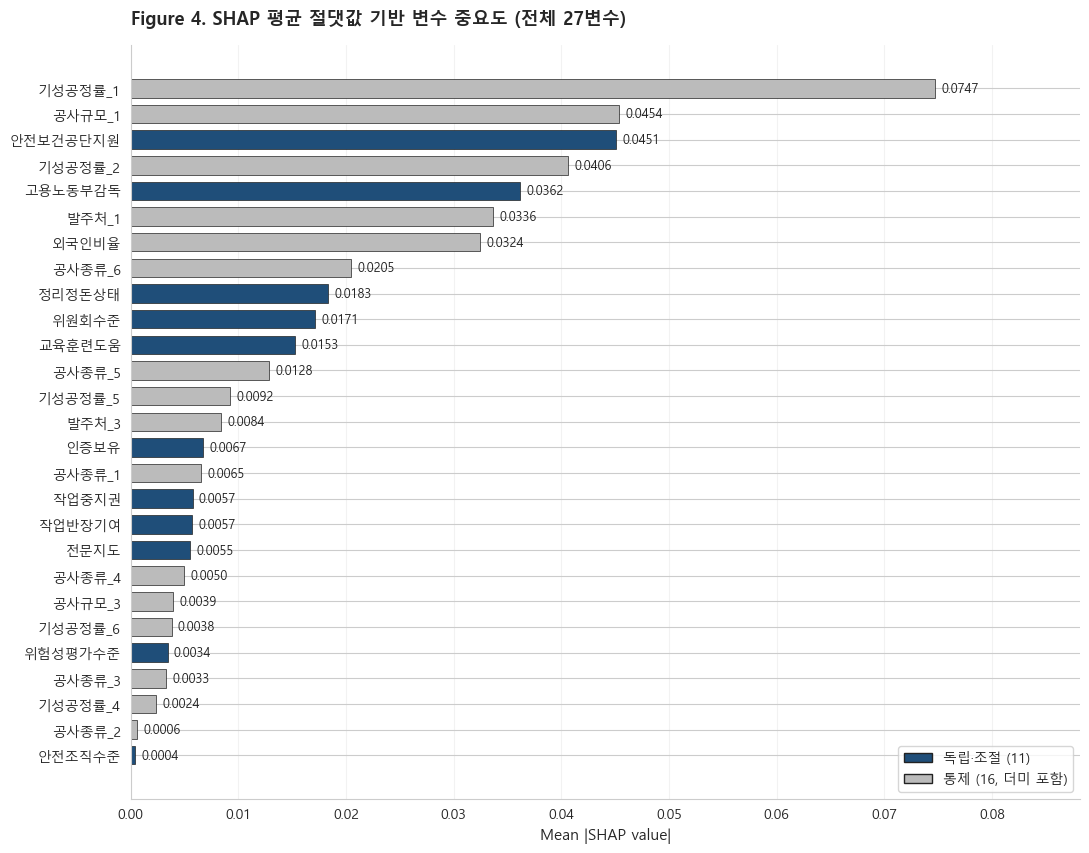

In [23]:
# Figure 4 - SHAP 평균 절댓값 기반 변수 중요도 (막대그래프)
from matplotlib.patches import Patch

control_set = set(DUMMY_COLS + VARS_CONTROL_NUM)
bar_df = table9a[['변수', 'mean|SHAP|']].copy()
bar_df['is_control'] = bar_df['변수'].isin(control_set)
# 상단(큰 값)이 보기 좋도록 오름차순 정렬 후 barh
bar_df = bar_df.sort_values('mean|SHAP|', ascending=True).reset_index(drop=True)

color_focus = '#1f4e79'   # dark navy — 독립·조절
color_ctrl  = '#bbbbbb'   # light gray — 통제
colors = [color_ctrl if c else color_focus for c in bar_df['is_control']]

fig, ax = plt.subplots(figsize=(11, max(6, 0.32 * len(bar_df))))
ax.barh(range(len(bar_df)), bar_df['mean|SHAP|'],
        color=colors, edgecolor='#222', linewidth=0.5, height=0.72)

ax.set_yticks(range(len(bar_df)))
ax.set_yticklabels(bar_df['변수'].tolist(), fontsize=10)

xmax = bar_df['mean|SHAP|'].max()
for i, val in enumerate(bar_df['mean|SHAP|']):
    ax.text(val + xmax * 0.008, i, f'{val:.4f}',
            va='center', fontsize=9, color='#222')

handles = [
    Patch(facecolor=color_focus, edgecolor='#222', label='독립·조절 (11)'),
    Patch(facecolor=color_ctrl,  edgecolor='#222', label='통제 (16, 더미 포함)')
]
ax.legend(handles=handles, loc='lower right', frameon=True, fontsize=10)

ax.set_xlabel('Mean |SHAP value|', fontsize=11)
ax.set_xlim(0, xmax * 1.18)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', alpha=0.25, lw=0.8)

ax.set_title('Figure 4. SHAP 평균 절댓값 기반 변수 중요도 (전체 27변수)',
             fontsize=13, fontweight='bold', loc='left', pad=15)

plt.tight_layout()
fig.savefig(FIGURES_DIR/'fig4_SHAP_변수중요도.png', **SAVE_KWARGS)
plt.show()


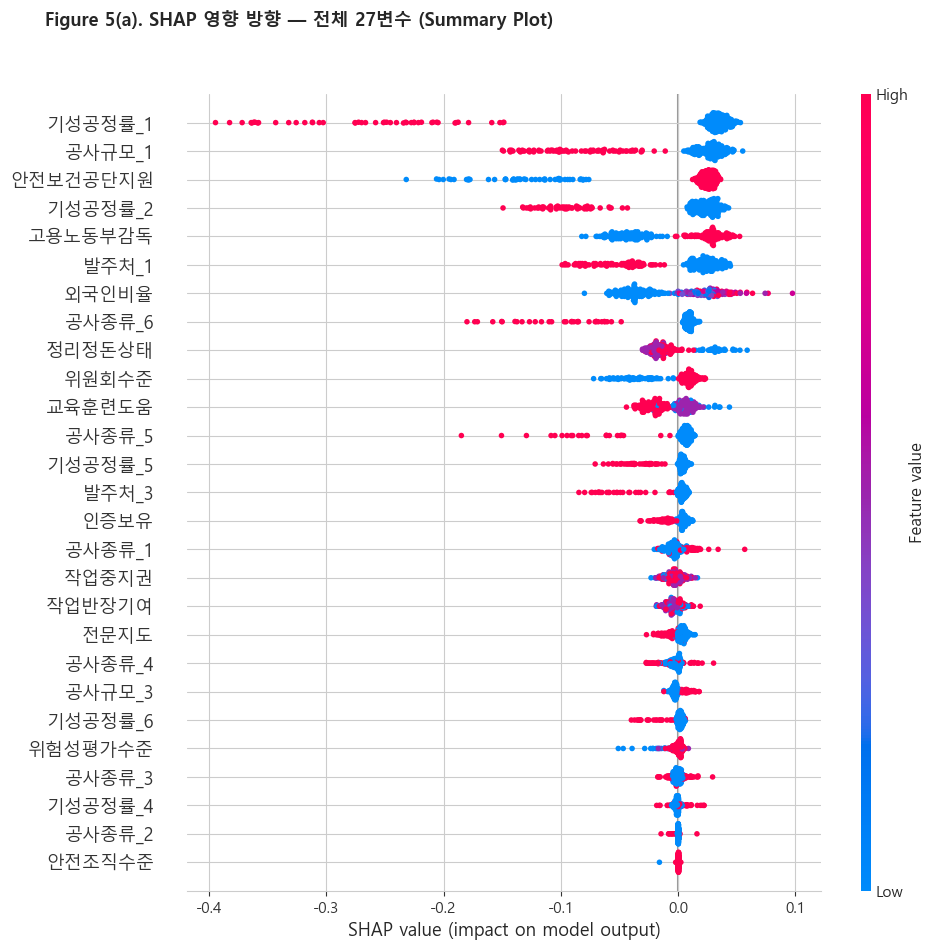

In [24]:
# Figure 5(a) - SHAP 영향 방향 (Summary Plot, 전체 27변수)
shap.summary_plot(shap_values, X_test, feature_names=FEATURE_COLS, show=False, max_display=27)
fig = plt.gcf(); fig.set_size_inches(10, 9.5)
fig.suptitle('Figure 5(a). SHAP 영향 방향 — 전체 27변수 (Summary Plot)',
             fontsize=13, fontweight='bold', y=0.995, x=0.05, ha='left')
plt.tight_layout(rect=[0, 0, 1, 0.965])
plt.savefig(FIGURES_DIR/'fig5a_SHAP_Summary_전체.png', **SAVE_KWARGS)
plt.show()


> **방법론적 차별점 — 본 연구의 핵심 기여**
>
> 키 페이퍼(Qurat Ul Ain & Rather 2025)는 변수 부분집합 해석을 위해 모델을 *재학습*하는 방식을 취했다.
> 본 연구는 **전체 27변수로 학습한 단일 모델의 SHAP 값을, 가시성 목적으로만 컬럼 필터링하여 Figure 5(b)에 표시**한다.
>
> - 모델 학습 1회, SHAP 계산 1회
> - **Figure 5(a)**: 전체 27변수의 영향 패턴
> - **Figure 5(b)**: 통제변수를 *시각적으로 마스킹*한 독립·조절 11변수만의 분포 — *재학습 없음*
>
> **재학습을 피하는 이유**: 통제변수를 빼고 모델을 재학습하면 안전관리 변수가 통제변수 효과를 흡수하여 OR·SHAP 모두 과대평가됨. 단일 모델 + 시각적 마스킹으로 *해석의 무결성*과 *가시성*을 동시 확보.

,순위,변수,mean|SHAP|
0,1,안전보건공단지원,0.04506
1,2,고용노동부감독,0.03615
2,3,정리정돈상태,0.01829
3,4,위원회수준,0.01712
4,5,교육훈련도움,0.01530
5,6,인증보유,0.00668
6,7,작업중지권,0.00574
7,8,작업반장기여,0.00569
8,9,전문지도,0.00548
9,10,위험성평가수준,0.00342


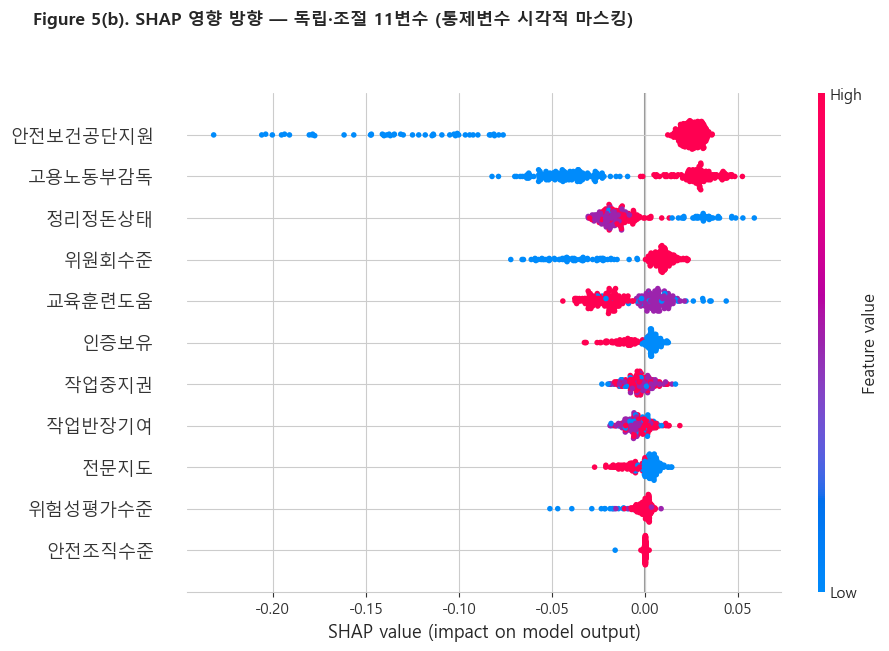

In [25]:
# Table 9b + Figure 5(b) - 독립·조절 11변수 (통제변수 시각적 마스킹, 재학습 X)
focus_vars = VARS_A + VARS_B + VARS_MOD       # 3 + 5 + 3 = 11
focus_idx = [FEATURE_COLS.index(c) for c in focus_vars]
shap_focus = shap_values[:, focus_idx]
X_focus = X_test.iloc[:, focus_idx]

mean_abs_focus = np.abs(shap_focus).mean(axis=0)
table9b = pd.DataFrame({'변수': focus_vars,
                        'mean|SHAP|': np.round(mean_abs_focus, 5)})
table9b = table9b.sort_values('mean|SHAP|', ascending=False).reset_index(drop=True)
table9b.insert(0, '순위', np.arange(1, len(table9b)+1))
table9b.to_csv(TABLES_DIR/'table9b_SHAP중요도_독립조절만.csv', index=False, encoding='utf-8-sig')
display(table9b)

# Figure 5(b) — Summary Plot 마스킹
shap.summary_plot(shap_focus, X_focus, feature_names=focus_vars, show=False, max_display=11)
fig = plt.gcf(); fig.set_size_inches(9.5, 6.5)
fig.suptitle('Figure 5(b). SHAP 영향 방향 — 독립·조절 11변수 (통제변수 시각적 마스킹)',
             fontsize=12.5, fontweight='bold', y=0.995, x=0.04, ha='left')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(FIGURES_DIR/'fig5b_SHAP_Summary_독립조절.png', **SAVE_KWARGS)
plt.show()


In [ ]:
# 정리정돈상태 SHAP 임계값 분석 (리커트 1~5)
key_var = '정리정돈상태'
key_idx = FEATURE_COLS.index(key_var)
key_shap = shap_values[:, key_idx]
key_vals = X_test[key_var].values

thr = pd.DataFrame({key_var: key_vals, 'SHAP': key_shap})
thr_summary = thr.groupby(key_var)['SHAP'].agg(['count','mean','std']).reset_index()
thr_summary.columns = [key_var, '관측수', '평균 SHAP', 'SD SHAP']
thr_summary['평균 SHAP'] = thr_summary['평균 SHAP'].round(5)
thr_summary['SD SHAP'] = thr_summary['SD SHAP'].round(5)
thr_summary.to_csv(TABLES_DIR/'table_정리정돈_SHAP임계.csv', index=False, encoding='utf-8-sig')
display(thr_summary)

# Figure 6 — 정리정돈상태 SHAP Dependence Plot
shap.dependence_plot(key_idx, shap_values, X_test, feature_names=FEATURE_COLS, show=False)
fig = plt.gcf(); fig.set_size_inches(8, 6)
plt.tight_layout()
plt.savefig(FIGURES_DIR/'fig6_정리정돈_Dependence.png', **SAVE_KWARGS)
plt.show()

In [27]:
# Permutation Importance + Table 10 — SHAP × PI × LR p-value 삼중 비교
pi = permutation_importance(
    shap_gs.best_estimator_, X_test, y_test,
    n_repeats=10, random_state=RANDOM_STATE, scoring='f1', n_jobs=-1
)
pi_df = pd.DataFrame({
    '변수': FEATURE_COLS,
    'Permutation Importance': np.round(pi.importances_mean, 5),
    'PI SD': np.round(pi.importances_std, 5)
})

# LR p-value: M4 (조절 포함, 상호작용 미포함) — 주효과 비교에 적합
lr_pv = m4.pvalues.drop('const', errors='ignore')
lr_df = pd.DataFrame({'변수': lr_pv.index, 'LR p값 (M4)': np.round(lr_pv.values, 4)})

shap_df = table9a[['변수', 'mean|SHAP|']]
table10 = shap_df.merge(pi_df, on='변수', how='outer').merge(lr_df, on='변수', how='outer')
table10 = table10.sort_values('mean|SHAP|', ascending=False).reset_index(drop=True)
table10.to_csv(TABLES_DIR/'table10_변수중요도_삼중비교.csv', index=False, encoding='utf-8-sig')
display(table10)

,변수,mean|SHAP|,Permutation Importance,PI SD,LR p값 (M4)
0,기성공정률_1,0.07473,0.07131,0.00948,0.0000
1,공사규모_1,0.04540,0.03725,0.01206,0.0001
2,안전보건공단지원,0.04506,0.00478,0.02133,0.0937
3,기성공정률_2,0.04062,0.04919,0.01411,0.0001
4,고용노동부감독,0.03615,0.00247,0.01187,0.9725
5,발주처_1,0.03363,0.01280,0.01597,0.0964
6,외국인비율,0.03244,0.02487,0.01591,0.4103
7,공사종류_6,0.02050,0.00037,0.00843,0.3490
8,정리정돈상태,0.01829,0.00443,0.01036,0.1329
9,위원회수준,0.01712,0.00633,0.01167,0.3197


In [ ]:
# Figure 7 — SHAP 상호작용 (24쌍) + Fig 6 히트맵
n_sample = min(200, len(X_test))
X_int = X_test.sample(n=n_sample, random_state=RANDOM_STATE)
inter_raw = explainer.shap_interaction_values(X_int)

if hasattr(inter_raw, 'values'):
    iv = inter_raw.values
    inter_vals = iv[..., 1] if iv.ndim == 4 else iv
elif isinstance(inter_raw, list):
    inter_vals = inter_raw[1]
elif np.ndim(inter_raw) == 4:
    inter_vals = np.array(inter_raw)[..., 1]
else:
    inter_vals = np.array(inter_raw)

ivs  = VARS_A + VARS_B           # 8 독립
mods = VARS_MOD                  # 3 조절
mat = np.zeros((len(ivs), len(mods)))
for i, x in enumerate(ivs):
    for j, m in enumerate(mods):
        ii = FEATURE_COLS.index(x)
        jj = FEATURE_COLS.index(m)
        mat[i, j] = np.abs(inter_vals[:, ii, jj]).mean()

fig, ax = plt.subplots(figsize=(7, 7))
sns.heatmap(mat, annot=True, fmt='.4f', cmap='YlOrRd',
            xticklabels=mods, yticklabels=ivs, ax=ax, cbar_kws={'shrink': 0.7})
ax.set_title('SHAP 상호작용 |값| 평균 (독립 8 × 조절 3)')
ax.set_xlabel('조절변수')
ax.set_ylabel('독립변수')
plt.tight_layout()
fig.savefig(FIGURES_DIR/'fig7_SHAP_상호작용히트맵.png', **SAVE_KWARGS)
plt.show()

inter_tbl = pd.DataFrame(mat, index=ivs, columns=mods)
inter_tbl.to_csv(TABLES_DIR/'table_SHAP_상호작용24쌍.csv', encoding='utf-8-sig')

---
## 검증 셀 — 핵심 수치 자동 출력

논문 작성에 필요한 핵심 수치를 한 번에 출력하고 `results/검증결과.txt`에 저장.

In [29]:
# === 핵심 수치 검증 ===
print('=' * 60)
print('핵심 수치 검증 (논문 작성용)')
print('=' * 60)

# 1. 정리정돈상태 (M5 주효과)
v = '정리정돈상태'
or_jrjd = float(np.exp(m5.params[v]))
p_jrjd  = float(m5.pvalues[v])
dir_jrjd = '보호(↓)' if or_jrjd < 1 else '위험(↑)'
print('\n[정리정돈상태] (M5 주효과)')
print(f'  OR = {or_jrjd:.3f}')
print(f'  p  = {p_jrjd:.4f}')
print(f'  방향: {dir_jrjd}')
print('  → 기대값: OR≈0.80, p<0.05')

# 2. 인증보유 × 고용노동부감독 (M5 상호작용)
ix = '인증보유__x__고용노동부감독'
or_ic = None; p_ic = None
if ix in m5.params.index:
    or_ic = float(np.exp(m5.params[ix]))
    p_ic  = float(m5.pvalues[ix])
    print('\n[인증보유 × 고용노동부감독]')
    print(f'  OR = {or_ic:.3f}')
    print(f'  p  = {p_ic:.4f}')
    print('  → 기대값: OR>1, p<0.05')
else:
    print('\n[인증보유 × 고용노동부감독]: 모델에 없음')

# 3. SHAP Top 5
print('\n[SHAP Top 5 (전체 27변수)]')
for _, row in table9a.head(5).iterrows():
    print(f"  {row['순위']}. {row['변수']}: {row['mean|SHAP|']:.4f}")

print('\n[SHAP Top 5 (독립·조절 11변수만)]')
for _, row in table9b.head(5).iterrows():
    print(f"  {row['순위']}. {row['변수']}: {row['mean|SHAP|']:.4f}")

# 4. RF + 최적 모델
print('\n[Random Forest 성능]')
print(f"  F1  = {results['RF']['F1']:.3f}")
print(f"  AUC = {results['RF']['ROC-AUC']:.3f}")
print('  → 기대값: F1≈0.52~0.55, AUC≈0.70~0.73')

print(f'\n[최적 모델: {best_name}]')
print(f"  F1={results[best_name]['F1']:.3f}, AUC={results[best_name]['ROC-AUC']:.3f}")

# 5. 4 모델 비교
print('\n[4개 모델 성능]')
for name in models_grid:
    r = results[name]
    print(f"  {name:9s}: F1={r['F1']:.3f}, AUC={r['ROC-AUC']:.3f}, P={r['정밀도']:.3f}, R={r['재현율']:.3f}")

# 6. 위계적 LR
print('\n[위계적 LR — R² 변화]')
for _, row in table4.iterrows():
    print(f"  {row['모형']:<22s}: R²={row['McFadden R²']:.4f}, AIC={row['AIC']:.1f}, BIC={row['BIC']:.1f}")

# 7. 유의 변수
print('\n[유의 변수 수]')
print(f"  M5 주효과 (p<0.05): {(table6['p값']<0.05).sum()} / {len(table6)}")
print(f"  M5 상호작용 (p<0.05): {(table7['p값']<0.05).sum()} / 24")
print(f"  M5 상호작용 (p<0.20): {(table7['p값']<0.20).sum()} / 24")

print('\n' + '=' * 60)
print('위 수치를 채팅에 보고하세요.')
print('=' * 60)

# 검증 결과를 텍스트로 저장
out = BASE_DIR / 'results' / '검증결과.txt'
with open(out, 'w', encoding='utf-8') as f:
    f.write(f'정리정돈상태 (M5): OR={or_jrjd:.4f}, p={p_jrjd:.5f}\n')
    if or_ic is not None:
        f.write(f'인증보유 × 고용노동부감독 (M5): OR={or_ic:.4f}, p={p_ic:.5f}\n')
    f.write('\nSHAP Top 5 (전체):\n')
    for _, row in table9a.head(5).iterrows():
        f.write(f"  {row['순위']}. {row['변수']}: {row['mean|SHAP|']:.4f}\n")
    f.write('\nSHAP Top 5 (독립·조절):\n')
    for _, row in table9b.head(5).iterrows():
        f.write(f"  {row['순위']}. {row['변수']}: {row['mean|SHAP|']:.4f}\n")
    f.write(f"\nRF: F1={results['RF']['F1']:.4f}, AUC={results['RF']['ROC-AUC']:.4f}\n")
    f.write(f"최적 모델: {best_name} (F1={results[best_name]['F1']:.4f}, AUC={results[best_name]['ROC-AUC']:.4f})\n")
print('\nresults/검증결과.txt 저장 완료.')

핵심 수치 검증 (논문 작성용)

[정리정돈상태] (M5 주효과)
  OR = 0.845
  p  = 0.1008
  방향: 보호(↓)
  → 기대값: OR≈0.80, p<0.05

[인증보유 × 고용노동부감독]
  OR = 1.174
  p  = 0.0634
  → 기대값: OR>1, p<0.05

[SHAP Top 5 (전체 27변수)]
  1. 기성공정률_1: 0.0747
  2. 공사규모_1: 0.0454
  3. 안전보건공단지원: 0.0451
  4. 기성공정률_2: 0.0406
  5. 고용노동부감독: 0.0362

[SHAP Top 5 (독립·조절 11변수만)]
  1. 안전보건공단지원: 0.0451
  2. 고용노동부감독: 0.0362
  3. 정리정돈상태: 0.0183
  4. 위원회수준: 0.0171
  5. 교육훈련도움: 0.0153

[Random Forest 성능]
  F1  = 0.517
  AUC = 0.705
  → 기대값: F1≈0.52~0.55, AUC≈0.70~0.73

[최적 모델: RF]
  F1=0.517, AUC=0.705

[4개 모델 성능]
  LR       : F1=0.497, AUC=0.704, P=0.423, R=0.603
  RF       : F1=0.517, AUC=0.705, P=0.460, R=0.590
  XGBoost  : F1=0.491, AUC=0.694, P=0.471, R=0.513
  LightGBM : F1=0.466, AUC=0.703, P=0.447, R=0.487

[위계적 LR — R² 변화]
  M1 (통제)               : R²=0.1495, AIC=1151.4, BIC=1236.5
  M2 (+A 내부관리)          : R²=0.1512, AIC=1155.2, BIC=1255.2
  M3 (+B 현장행동)          : R²=0.1541, AIC=1161.4, BIC=1286.4
  M4 (+조절)              : R²=0.1565, AI

---
## 결과 산출물 요약

### 표 (`results/tables/`)
- `table1_기술통계_연속.csv` — 연속/순서형 기술통계 + t-test
- `table2_기술통계_범주형.csv` — 범주형 기술통계 + χ²
- `table3_VIF.csv` — 다중공선성 진단
- `table4_LR_위계비교.csv` — M1~M5 위계적 비교 (LL, R², AIC, BIC)
- `table5_LR_우도비검정.csv` — 단계별 LR test
- `table6_LR_M5주효과.csv` — M5 주효과 (β, OR, 95% CI)
- `table7_LR_조절효과24쌍.csv` — 24개 상호작용항
- `table8_ML성능비교.csv` — 4개 모델 성능
- `table9a_SHAP중요도_전체.csv` — 전체 27변수 SHAP
- `table9b_SHAP중요도_독립조절만.csv` — 독립·조절 11변수 SHAP
- `table10_변수중요도_삼중비교.csv` — SHAP × PI × LR p-value
- `table_정리정돈_SHAP임계.csv` — 정리정돈 임계값별 SHAP
- `table_SHAP_상호작용24쌍.csv` — 24쌍 상호작용 |SHAP|

### 그림 (`results/figures/`)
- `fig1_종속변수분포.png`
- `fig_상관관계.png`
- `fig2_상호작용효과.png` — LR 상호작용 OR
- `fig3_ROC곡선.png` — 4 모델 ROC
- `fig4_SHAP_변수중요도.png` - Figure 4 (SHAP 평균 절댓값 막대그래프)
- `fig5a_SHAP_Summary_전체.png` / `fig5b_SHAP_Summary_독립조절.png` - Figure 5 (a)·(b)
- `fig6_정리정돈_Dependence.png` - Figure 6 (정리정돈상태 SHAP Dependence)
- `fig7_SHAP_상호작용히트맵.png` - Figure 7 (SHAP 상호작용 히트맵)